## Problem Statement 

#### Deep Learning (Assignment Project)
Handwritten Digit Classification using CNN & RNN
Project Dataset: MNIST Digit Classification
Problem Statement
Handwritten digit recognition is a fundamental problem in computer vision with applications in postal automation, bank cheque processing, and digitising handwritten documents. Traditional machine learning methods require manual feature extraction, which can limit performance and scalability.
The objective of this project is to develop a Convolutional Neural Network (CNN) and an Recurrent Neural Network (RNN) capable of automatically learning spatial features from handwritten images and accurately classifying digits from 0–9 using the MNIST dataset. We'll then compare the performance of both these neural networks.
The dataset contains grayscale images of handwritten digits, each of size 28 × 28 pixels. The goal is to train a CNN model & an RNN model that can correctly classify each image into one of the ten digit classes.
The project involves designing an appropriate CNN & RNN architecture, training the model, evaluating its performance using metrics such as accuracy and confusion matrix, and analysing how different architectural choices affect classification performance.
Expected Outcome
A trained CNN & RNN model capable of recognising handwritten digits with high accuracy (typically >95%).

### PART 1: Import Libraries & Load Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST

from tqdm import tqdm

### PART 2: Data Preprocessing

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [4]:
train_dataset = MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:07<00:00, 1.33MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.01MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.22MB/s]


In [5]:
train_size = int(len(train_dataset) * 0.9)
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Training Samples :", len(train_data))
print("Validation Samples :", len(val_data))
print("Testing Samples :", len(test_dataset))

Training Samples : 54000
Validation Samples : 6000
Testing Samples : 10000


In [6]:
batch_size = 64

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

### PART 3: Visualize Dataset

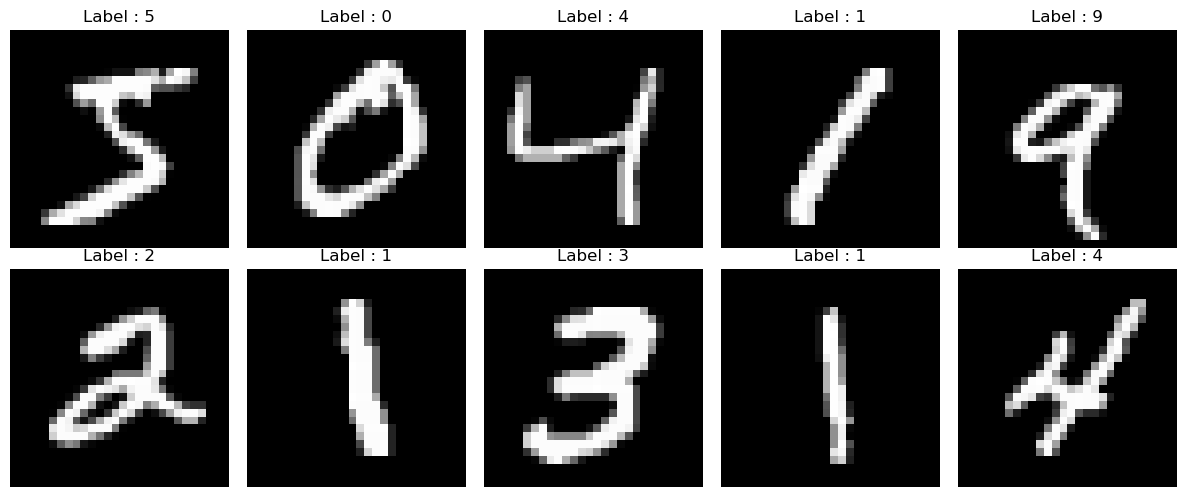

In [7]:
classes = [0,1,2,3,4,5,6,7,8,9]

plt.figure(figsize=(12,5))

for i in range(10):

    image, label = train_dataset[i]

    plt.subplot(2,5,i+1)

    plt.imshow(image.squeeze(), cmap='gray')

    plt.title(f"Label : {label}")

    plt.axis('off')

plt.tight_layout()

plt.show()

### PART 4: CNN Model

In [8]:
class CNN(nn.Module):

    def __init__(self):

        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(1,32,kernel_size=3,padding=1),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3,padding=1),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64,128,kernel_size=3,padding=1),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2)

        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128*3*3,256),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256,128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128,10)

        )

    def forward(self,x):

        x = self.conv_layers(x)

        x = self.fc_layers(x)

        return x

In [9]:
cnn_model = CNN().to(device)

print(cnn_model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=256, bias=True)
  

### PART 5: Loss Function & Optimizer

In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

In [11]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [12]:
train_loss_history = []
val_loss_history = []

train_acc_history = []
val_acc_history = []

In [ ]:
# Starting With CNN

### PART 2: CNN Training

In [14]:
# Hyperparameters
epochs = 15
best_val_accuracy = 0.0

# Early Stopping
patience = 3
counter = 0

In [15]:
for epoch in range(epochs):

    #########################
    # Training Phase
    #########################

    cnn_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]")

    for images, labels in train_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = cnn_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    #########################
    # Validation Phase
    #########################

    cnn_model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = cnn_model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)

    val_accuracy = 100 * val_correct / val_total

    #########################
    # Save History
    #########################

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    train_acc_history.append(train_accuracy)
    val_acc_history.append(val_accuracy)

    #########################
    # Scheduler
    #########################

    scheduler.step(val_loss)

    #########################
    # Save Best Model
    #########################

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(cnn_model.state_dict(), "best_cnn_model.pth")

        counter = 0

    else:

        counter += 1

    #########################
    # Print Results
    #########################

    print(f"\nEpoch [{epoch+1}/{epochs}]")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Validation Loss : {val_loss:.4f}")

    print(f"Train Accuracy : {train_accuracy:.2f}%")

    print(f"Validation Accuracy : {val_accuracy:.2f}%")

    #########################
    # Early Stopping
    #########################

    if counter >= patience:

        print("\nEarly Stopping Triggered!")

        break

Epoch 1/15 [Training]: 100%|██████████| 844/844 [01:26<00:00,  9.80it/s, loss=0.198]  



Epoch [1/15]
Train Loss : 0.2075
Validation Loss : 0.0663
Train Accuracy : 93.52%
Validation Accuracy : 98.07%


Epoch 2/15 [Training]: 100%|██████████| 844/844 [01:25<00:00,  9.83it/s, loss=0.0435] 



Epoch [2/15]
Train Loss : 0.0708
Validation Loss : 0.0437
Train Accuracy : 97.97%
Validation Accuracy : 98.73%


Epoch 3/15 [Training]: 100%|██████████| 844/844 [01:36<00:00,  8.78it/s, loss=0.0981] 


...


Epoch [8/15]
Train Loss : 0.0255
Validation Loss : 0.0370
Train Accuracy : 99.25%
Validation Accuracy : 99.07%


Epoch 9/15 [Training]: 100%|██████████| 844/844 [02:29<00:00,  5.66it/s, loss=0.13]    



Epoch [9/15]
Train Loss : 0.0214
Validation Loss : 0.0418
Train Accuracy : 99.42%
Validation Accuracy : 98.98%


Epoch 10/15 [Training]: 100%|██████████| 844/844 [02:27<00:00,  5.73it/s, loss=0.135]   



Epoch [10/15]
Train Loss : 0.0209
Validation Loss : 0.0376
Train Accuracy : 99.35%
Validation Accuracy : 98.93%

Early Stopping Triggered!


In [16]:
cnn_model.load_state_dict(torch.load("best_cnn_model.pth"))

print("Best CNN model loaded successfully!")

Best CNN model loaded successfully!


### PART 3: CNN Testing

In [17]:
cnn_model.eval()

test_correct = 0
test_total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = cnn_model(images)

        _, predicted = torch.max(outputs.data, 1)

        test_total += labels.size(0)

        test_correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * test_correct / test_total

print(f"\nCNN Test Accuracy : {test_accuracy:.2f}%")


CNN Test Accuracy : 99.33%


### PART 4: CNN Confusion Matrix

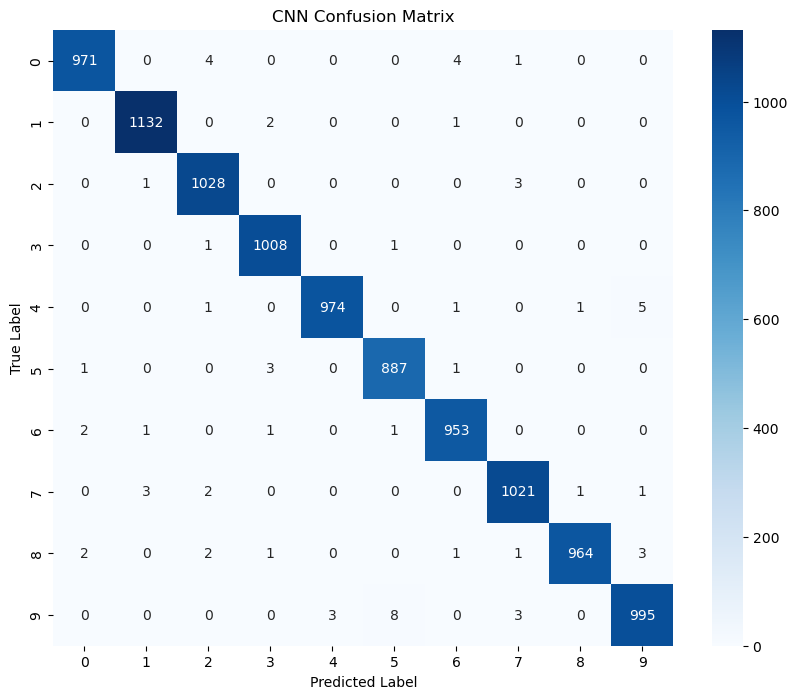

In [18]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")

plt.show()

### PART 5: Classification Report

In [19]:
print(classification_report(all_labels, all_predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      1.00      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### PART 6: Training & Validation Loss Graph

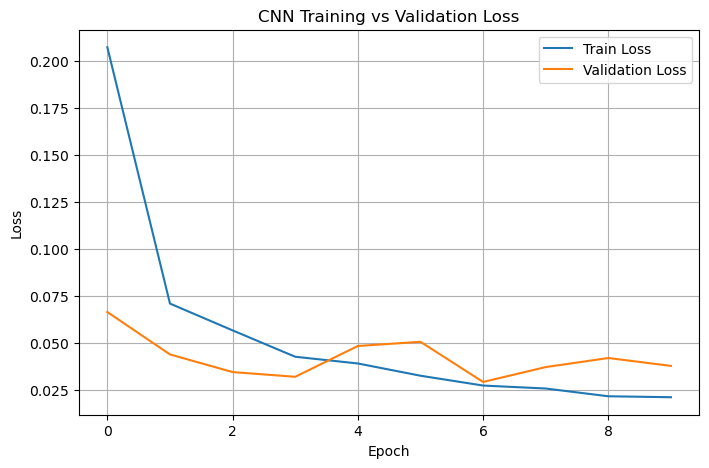

In [20]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_history, label="Train Loss")

plt.plot(val_loss_history, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("CNN Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

### PART 7: Training & Validation Accuracy Graph

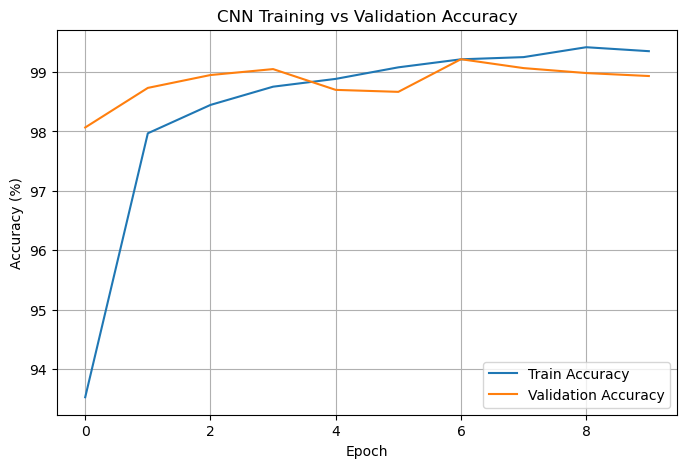

In [21]:
plt.figure(figsize=(8,5))

plt.plot(train_acc_history, label="Train Accuracy")

plt.plot(val_acc_history, label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("CNN Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

### PART 8: Display Sample Predictions

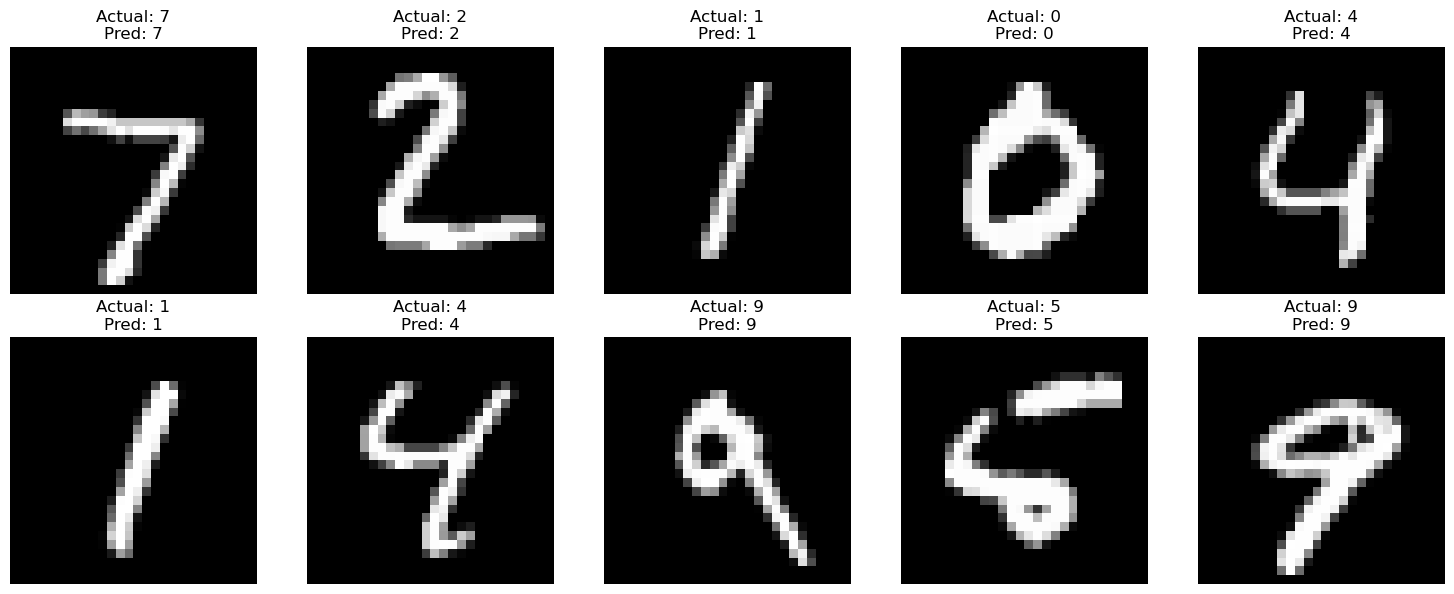

In [22]:
classes = list(range(10))

images, labels = next(iter(test_loader))

images = images.to(device)

outputs = cnn_model(images)

_, predicted = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(15,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(f"Actual: {labels[i]}\nPred: {predicted[i].cpu().item()}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
# RNN

### PART 3: RNN (LSTM) Model for MNIST

In [23]:
class RNNModel(nn.Module):

    def __init__(self, input_size=28, hidden_size=128, num_layers=2, num_classes=10):

        super(RNNModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        # x shape: (batch_size, 1, 28, 28)

        x = x.squeeze(1)

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        out, _ = self.lstm(x, (h0, c0))

        out = out[:, -1, :]

        out = self.dropout(out)

        out = self.fc(out)

        return out

In [24]:
rnn_model = RNNModel().to(device)

print(rnn_model)

RNNModel(
  (lstm): LSTM(28, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)


In [25]:
criterion_rnn = nn.CrossEntropyLoss()

optimizer_rnn = optim.Adam(
    rnn_model.parameters(),
    lr=0.001
)

scheduler_rnn = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_rnn,
    mode='min',
    factor=0.5,
    patience=2
)

In [26]:
rnn_train_loss = []
rnn_val_loss = []

rnn_train_acc = []
rnn_val_acc = []

In [27]:
epochs = 15

best_val_accuracy = 0

patience = 3

counter = 0

In [28]:
for epoch in range(epochs):

    ############################
    # Training
    ############################

    rnn_model.train()

    running_loss = 0

    correct = 0

    total = 0

    train_bar = tqdm(train_loader,
                     desc=f"Epoch {epoch+1}/{epochs} [Training]")

    for images, labels in train_bar:

        images = images.to(device)

        labels = labels.to(device)

        optimizer_rnn.zero_grad()

        outputs = rnn_model(images)

        loss = criterion_rnn(outputs, labels)

        loss.backward()

        optimizer_rnn.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted==labels).sum().item()

        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss/len(train_loader)

    train_accuracy = 100*correct/total

    ############################
    # Validation
    ############################

    rnn_model.eval()

    val_loss = 0

    val_correct = 0

    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = rnn_model(images)

            loss = criterion_rnn(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            val_total += labels.size(0)

            val_correct += (predicted==labels).sum().item()

    val_loss = val_loss/len(val_loader)

    val_accuracy = 100*val_correct/val_total

    rnn_train_loss.append(train_loss)
    rnn_val_loss.append(val_loss)

    rnn_train_acc.append(train_accuracy)
    rnn_val_acc.append(val_accuracy)

    scheduler_rnn.step(val_loss)

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(rnn_model.state_dict(),"best_rnn_model.pth")

        counter = 0

    else:

        counter += 1

    print(f"\nEpoch {epoch+1}/{epochs}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Validation Loss : {val_loss:.4f}")

    print(f"Train Accuracy : {train_accuracy:.2f}%")

    print(f"Validation Accuracy : {val_accuracy:.2f}%")

    if counter >= patience:

        print("\nEarly Stopping!")

        break

Epoch 1/15 [Training]: 100%|██████████| 844/844 [01:23<00:00, 10.16it/s, loss=0.242] 



Epoch 1/15
Train Loss : 0.3674
Validation Loss : 0.1268
Train Accuracy : 88.04%
Validation Accuracy : 96.37%


Epoch 2/15 [Training]: 100%|██████████| 844/844 [01:32<00:00,  9.08it/s, loss=0.112]  



Epoch 2/15
Train Loss : 0.1003
Validation Loss : 0.0886
Train Accuracy : 97.13%
Validation Accuracy : 97.37%


Epoch 3/15 [Training]: 100%|██████████| 844/844 [01:37<00:00,  8.63it/s, loss=0.0479] 


...


Epoch 11/15
Train Loss : 0.0117
Validation Loss : 0.0465
Train Accuracy : 99.64%
Validation Accuracy : 98.92%


Epoch 12/15 [Training]: 100%|██████████| 844/844 [03:02<00:00,  4.63it/s, loss=0.000375]



Epoch 12/15
Train Loss : 0.0104
Validation Loss : 0.0531
Train Accuracy : 99.69%
Validation Accuracy : 98.78%


Epoch 13/15 [Training]: 100%|██████████| 844/844 [02:22<00:00,  5.93it/s, loss=0.00254] 



Epoch 13/15
Train Loss : 0.0098
Validation Loss : 0.0544
Train Accuracy : 99.70%
Validation Accuracy : 98.85%

Early Stopping!


In [29]:
rnn_model.load_state_dict(torch.load("best_rnn_model.pth"))

print("Best LSTM model loaded successfully!")

Best LSTM model loaded successfully!


In [30]:
rnn_model.eval()

correct = 0

total = 0

all_predictions_rnn = []

all_labels_rnn = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = rnn_model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted==labels).sum().item()

        all_predictions_rnn.extend(predicted.cpu().numpy())

        all_labels_rnn.extend(labels.cpu().numpy())

rnn_accuracy = 100*correct/total

print(f"RNN Test Accuracy : {rnn_accuracy:.2f}%")

RNN Test Accuracy : 98.82%


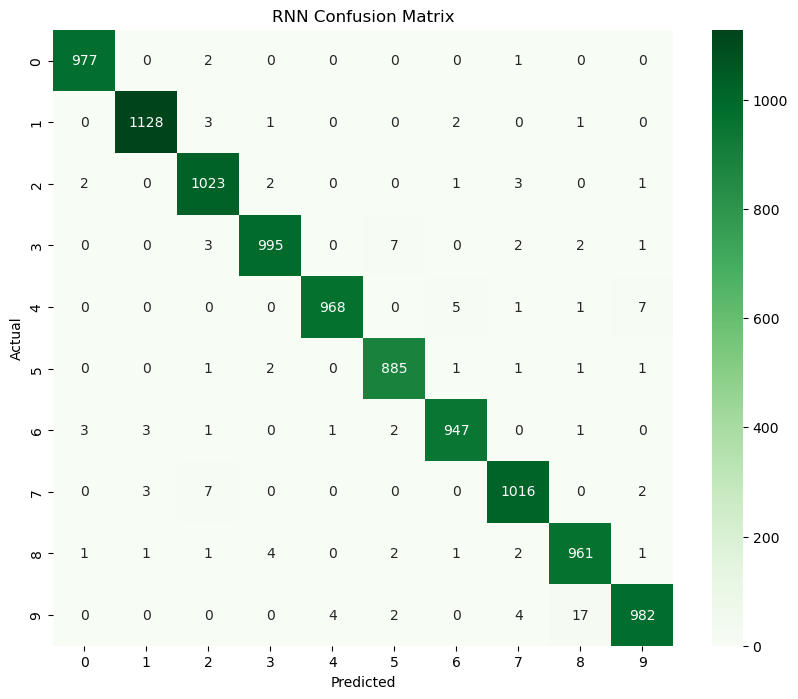

In [31]:
cm = confusion_matrix(all_labels_rnn, all_predictions_rnn)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("RNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [32]:
print(classification_report(
    all_labels_rnn,
    all_predictions_rnn
))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



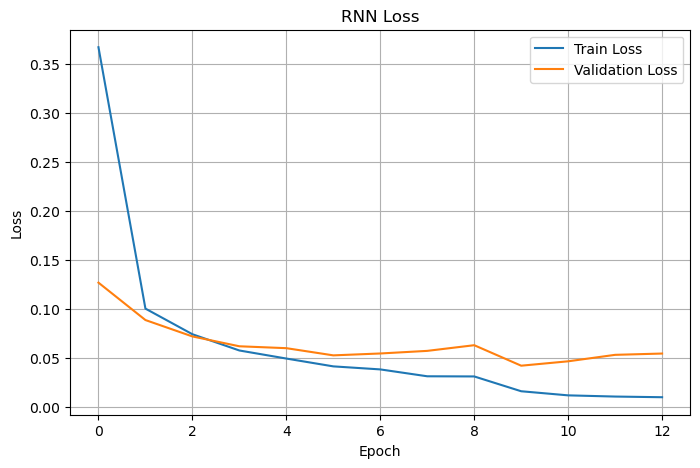

In [33]:
plt.figure(figsize=(8,5))

plt.plot(rnn_train_loss,label="Train Loss")

plt.plot(rnn_val_loss,label="Validation Loss")

plt.title("RNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

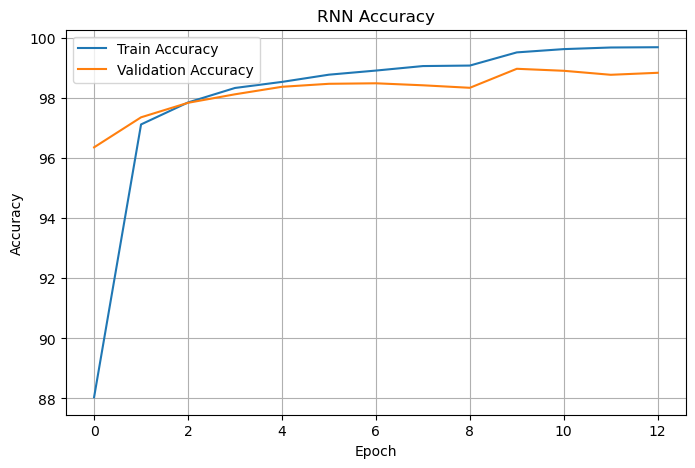

In [34]:
plt.figure(figsize=(8,5))

plt.plot(rnn_train_acc,label="Train Accuracy")

plt.plot(rnn_val_acc,label="Validation Accuracy")

plt.title("RNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

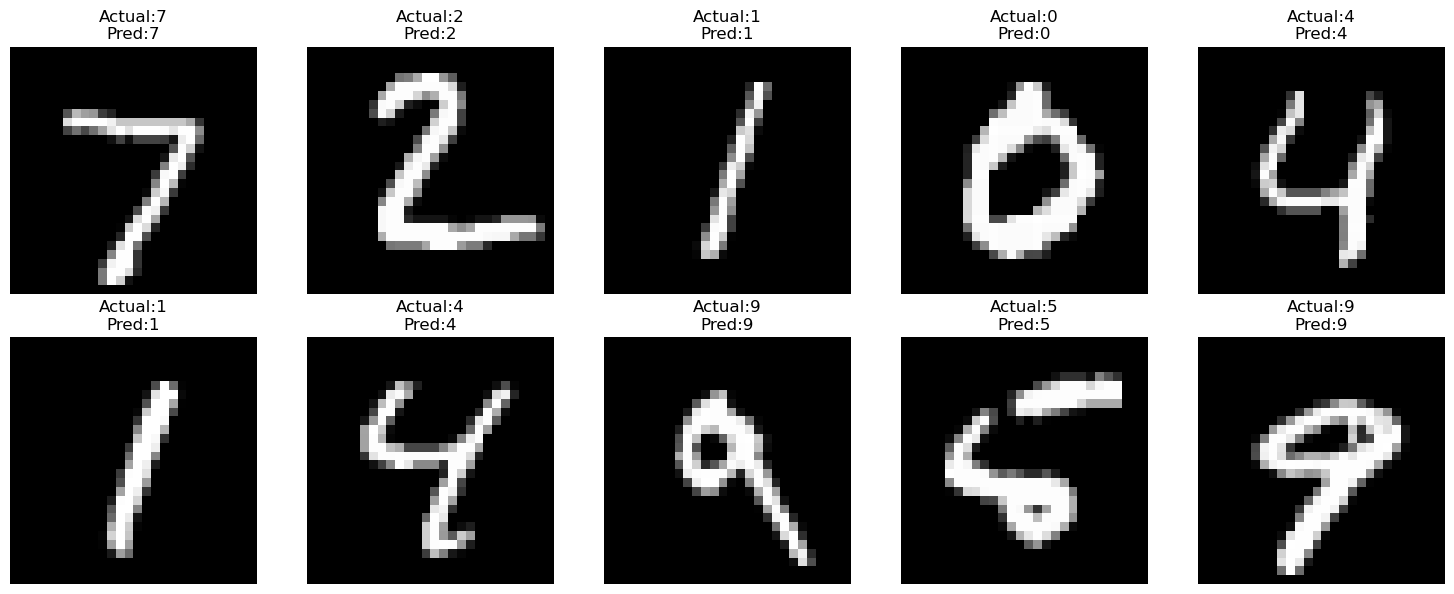

In [35]:
images, labels = next(iter(test_loader))

images = images.to(device)

outputs = rnn_model(images)

_, predicted = torch.max(outputs,1)

images = images.cpu()

plt.figure(figsize=(15,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i].squeeze(), cmap='gray')

    plt.title(f"Actual:{labels[i]}\nPred:{predicted[i].cpu().item()}")

    plt.axis('off')

plt.tight_layout()

plt.show()

In [ ]:
# CNN vs RNN

### PART 4: CNN vs RNN Comparison

In [36]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["CNN", "RNN (LSTM)"],
    "Test Accuracy (%)": [99.33, 98.82]
})

comparison

,Model,Test Accuracy (%)
0,CNN,99.33
1,RNN (LSTM),98.82


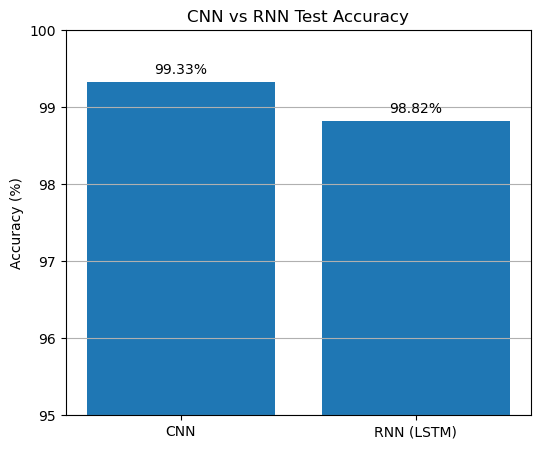

In [37]:
plt.figure(figsize=(6,5))

plt.bar(comparison["Model"], comparison["Test Accuracy (%)"])

plt.title("CNN vs RNN Test Accuracy")

plt.ylabel("Accuracy (%)")

for i, v in enumerate(comparison["Test Accuracy (%)"]):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center')

plt.ylim(95,100)

plt.grid(axis='y')

plt.show()

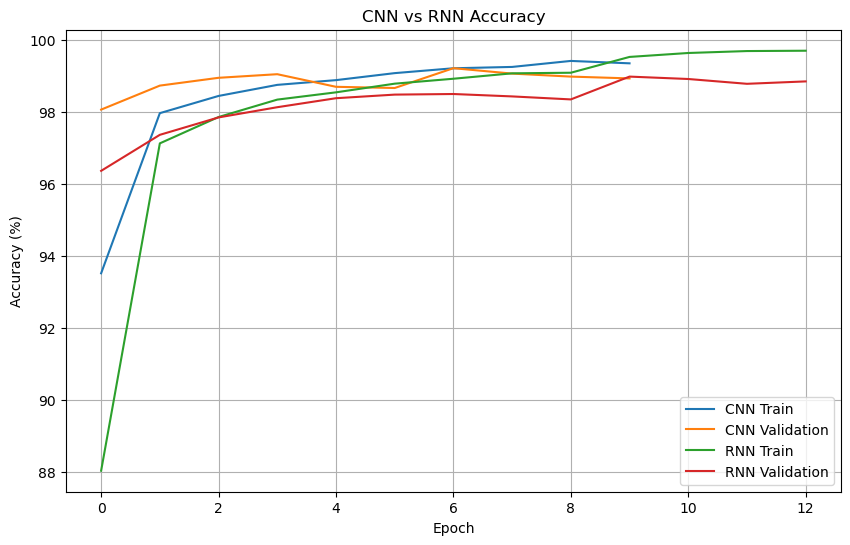

In [38]:
plt.figure(figsize=(10,6))

plt.plot(train_acc_history, label="CNN Train")

plt.plot(val_acc_history, label="CNN Validation")

plt.plot(rnn_train_acc, label="RNN Train")

plt.plot(rnn_val_acc, label="RNN Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("CNN vs RNN Accuracy")

plt.legend()

plt.grid(True)

plt.show()

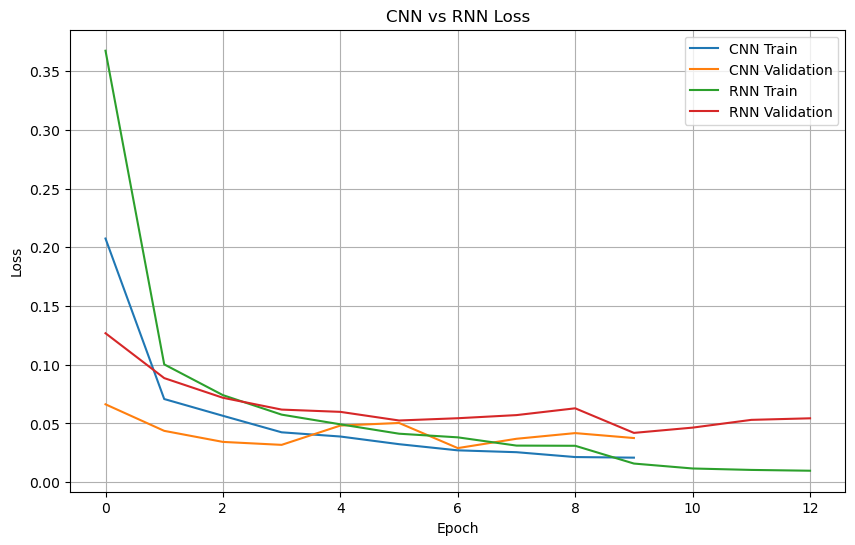

In [39]:
plt.figure(figsize=(10,6))

plt.plot(train_loss_history, label="CNN Train")

plt.plot(val_loss_history, label="CNN Validation")

plt.plot(rnn_train_loss, label="RNN Train")

plt.plot(rnn_val_loss, label="RNN Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("CNN vs RNN Loss")

plt.legend()

plt.grid(True)

plt.show()

### PART 5: Results and Discussion

#### Results and Discussion

The Convolutional Neural Network (CNN) achieved a test accuracy of **99.33%**, while the Recurrent Neural Network (LSTM) achieved **98.82%** on the MNIST handwritten digit dataset.

CNN outperformed the RNN because convolutional layers are specifically designed to learn spatial features such as edges, curves, and shapes from images. Pooling layers further help by reducing dimensionality while preserving important features.

The LSTM model also performed exceptionally well by treating each image as a sequence of rows. However, since LSTMs are primarily designed for sequential data rather than image data, they are slightly less effective at capturing spatial relationships compared to CNNs.

Both models achieved accuracy well above the required 95%, demonstrating their effectiveness for handwritten digit recognition.

### PART 6: Advantages and Limitations

####  Advantages of CNN

- Excellent at extracting spatial features from images.
- High classification accuracy.
- Robust to translation and small distortions.
- Computationally efficient for image tasks.

#### Limitations of CNN

- Requires more computational resources.
- Needs a relatively large amount of training data.

#### Advantages of RNN (LSTM)

- Designed for sequential data.
- Can capture dependencies across image rows.
- Performs well even when treating images as sequences.

#### Limitations of RNN

- Slower training compared to CNN.
- Not specifically designed for image feature extraction.
- Slightly lower accuracy on image classification tasks.

### PART 7: Conclusion

####  Conclusion

In this project, two deep learning models, CNN and LSTM-based RNN, were implemented using PyTorch to classify handwritten digits from the MNIST dataset.

The CNN model achieved a test accuracy of **99.33%**, while the LSTM model achieved **98.82%**, both exceeding the assignment requirement of 95% accuracy.

The experimental results demonstrate that CNN is more suitable for image classification due to its ability to extract hierarchical spatial features. Although the LSTM-based RNN also achieved excellent performance, it is comparatively less efficient for image-based tasks.

Overall, both models successfully classified handwritten digits with high accuracy, fulfilling the objectives of the assignment.

### PART 8: Future Scope

####  Future Scope

- Apply the models to larger handwritten datasets such as EMNIST.
- Improve performance using data augmentation.
- Implement transfer learning with pre-trained CNN architectures.
- Explore hybrid CNN-LSTM models for complex image sequence tasks.
- Deploy the trained model as a web application using Flask or Streamlit.